In [132]:
# Numpy
import numpy as np

# Matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt

#Pandas


# Scikit-learn
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.base import BaseEstimator
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve

In [107]:
# Load the dataset found in scikit - learn and see its structure with keys.()
mnist = fetch_openml('mnist_784', version = 1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [108]:
X, y = mnist['data'], mnist['target']
X.shape


(70000, 784)

In [109]:
y.shape

(70000,)

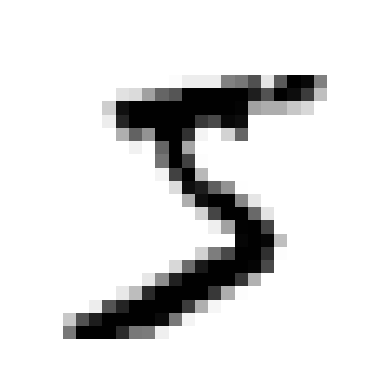

In [110]:
some_digit_image_show = X.iloc[0].to_numpy()
some_digit_image = some_digit_image_show.reshape(28,28)

plt.imshow(some_digit_image, cmap = mpl.cm.binary, interpolation = "nearest")
plt.axis("off")
plt.show()

In [111]:
y[0]


'5'

In [112]:
y = y.astype(np.uint8)

### Splitting the dataset into train and test

The MNIST dataset is actually already split into a training set (the first 60.000 images) and a test set (the last 10.000)

In [113]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

### Binary Classifier to start

First, let's simplify the classification task of all digits to only if is 5 or not. Let's build a "5-detector".

In [114]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

### SGD classifier 

Using a SGD classifier as a model to classify between 5 and not 5. We are using it just because its good dealing with very large datasets, in part because it trains every instance independly, one at a time. 

In [115]:
sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [116]:
some_digit = X.iloc[[0]]
sgd_clf.predict(some_digit)

array([ True])

### Performance Measures

In [117]:
# Implementing Cross Validation

skfolds = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train.iloc[train_index]
    y_train_folds = y_train_5.iloc[train_index]
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train_5.iloc[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))



0.9042
0.9477
0.96785


### Dumb Classifier and Problem with Accuracy in Classification

In [118]:
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

Great accuracy results, but with an unbalanced dataset this metric is misleading. If 90% of the data are ‘not-5s’ and you always predict ‘not-5’, you will be right 90% of the time — even with a terrible model.

### Confusion Matrix

In [119]:
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3)

In [120]:
confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

Each row in the confusion matrix represents an actual class, while each column represents a predicted class.
53892 true negatives(TN) and 3530 true positives(TP) (main diagonal). 1891 false negatives (FN) and 687 false positives(FN).

### Precision
Using a more concise metric to analise the classifier (precision is also called the accuracy of the positive predictions).



$$Precision = \frac{TP}{TP + FP}$$

### Recall (also called sensitivity or true positive rate, TPR)
Is the ratio of positive instances that are correctly detected by the classifier. 


$$Recall = \frac{TP}{TP + FN}$$

In [121]:
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [122]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

### F-1 Score

It's a convinient way of combining precision and recall in one metric, as the f-1 score is the harmonic mean of the two. Moreover, it's a simple way of comparing two classifiers.

$$F1 = \frac{2}{\frac{1}{precision} + \frac{1}{recall}}$$

In [123]:
f1_score(y_train_5, y_train_pred)

0.7325171197343847

### Decision Threshold for classifiers
Using the decision_function to return the score calculate by the model for the instance [0] (the one we defined some_digit thas in reality was a 5).
We can try different thresholds and compare to the score calculated by the model for this digit.

In [124]:
y_scores = sgd_clf.decision_function(some_digit)
print(y_scores)

threshold = 0
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)

[2164.22030239]
[ True]


### Decision Threshold for each instance
What can be really interesting it would be to get the score the model calculated to each instance we have, no only 'some_digit' and use the precision_recall_curve function to analyse different thresholds and how this impact on the metrics.

In [125]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 5, method = 'decision_function')

In [126]:
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

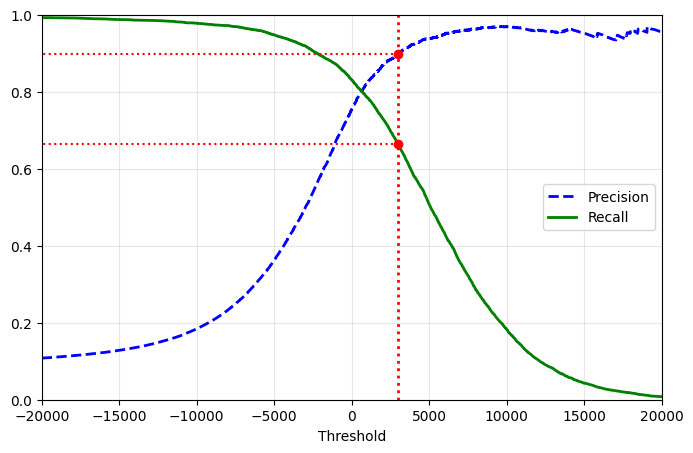

In [127]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds, chosen_threshold=3000):
    plt.figure(figsize=(8, 5))

    p = precisions[:-1]
    r = recalls[:-1]

    plt.plot(thresholds, p, "b--", linewidth=2, label="Precision")
    plt.plot(thresholds, r, "g-", linewidth=2, label="Recall")
    plt.axvline(chosen_threshold, color="red", linestyle=":", linewidth=2)
    plt.xlim(-20000, 20000)


    idx = (thresholds >= chosen_threshold).argmax()
    plt.plot(chosen_threshold, p[idx], "ro")
    plt.plot(chosen_threshold, r[idx], "ro")
    plt.hlines(p[idx], xmin=thresholds[0], xmax=chosen_threshold, colors="red", linestyles=":")
    plt.hlines(r[idx], xmin=thresholds[0], xmax=chosen_threshold, colors="red", linestyles=":")

    plt.xlabel("Threshold")
    plt.ylim([0, 1])
    plt.grid(True, alpha=0.3)
    plt.legend(loc="center right")
    plt.show()

plot_precision_recall_vs_threshold(precisions, recalls, thresholds, chosen_threshold = 3000)


With this plot we can see clearly the precision-recall trade-off and even choose a value of precision or recall based on our project.

Consider that we want 90% precision, we can use the np.argmax() function to return to us the lowest threshold to achieve 90% precision. 
We want the lowest one because knowing the trade-off, we know that increasing precision will decrease recall.

In [128]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
threshold_90_precision

np.float64(3045.9258227055584)

To make predictions (on the training set for now), instead of calling the classifier’s predict() method, you can just run this code:

In [129]:
y_train_pred_90 = (y_scores >= threshold_90_precision)
print(y_train_pred_90)

[ True False False ...  True False False]


In [130]:
precision_score(y_train_5, y_train_pred_90)

0.9002016129032258

In [131]:
recall_score(y_train_5, y_train_pred_90)

0.6589190186312488

## The ROC Curve

The receiver operating characteristic (ROC) plots the true positive rate (TPR - Recall) against the false positive rate (FPR).

- FPR = 1 - TNR
- TNR = Specificity
- TPR = Sensitivity (Recall)

The ROC curve plots Sensitivity against (1 - Specificity)